# 06 - V2 XGBoost Model Training and Evaluation

This notebook trains and evaluates the V2 price-drop prediction model for the Smart Buy Window Predictor project.

The input dataset is: `data/processed/features_v2.csv`

The model predicts whether a product will have a **meaningful price drop within the next 14 days**.

The target variable is: `label_drop_14d`

A row is labelled `1` if the selected modelling price drops by:

- at least **5%**, and
- at least **$5**

within the next 14 days.

This combined threshold is used because a percentage-only drop may not be meaningful for low-priced products. For example, a 5% drop on a $20 item is only $1, which is unlikely to justify delaying a purchase. Requiring both a relative percentage drop and an absolute dollar saving better matches the target user: a deal-conscious shopper making a considered, deferrable purchase.

The notebook compares three approaches:

1. **Rule-based baseline**  
   Predicts a future drop if the current price is above the 30-day rolling average.

2. **Logistic regression baseline**  
   Uses the same engineered feature set as XGBoost, but with a simpler linear model.

3. **XGBoost classifier**  
   Uses price-history, sales-rank, offer-count, price-source, category, and retail-event features to predict future meaningful drops.

The data is split chronologically:

- training: historical data up to 2024-12-31
- validation: 2025-01-01 to 2025-12-31
- test: 2026-01-01 onward

The validation set is used for model selection and threshold tuning. The test set is used only once at the end for final evaluation.

The final user-facing recommendation is evaluated using a **three-zone system**:

- **BUY NOW** when the predicted probability of a meaningful drop is low
- **UNCERTAIN** when the model is not confident enough
- **WAIT** when the predicted probability of a meaningful drop is high

The binary threshold is used for model comparison and confusion-matrix analysis, while the three-zone system is the more realistic user-facing recommendation design.

In [1]:
# Cell 2 - Import Libraries and Set Display Options

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.colheader_justify", "left")

In [2]:
# Cell 3 - Load Feature Dataset Load dataset, define features, split data

PROJECT_ROOT = Path("/Users/hibaswaidan/Desktop/smart-buy-window-predictor")

FEATURES_PATH = PROJECT_ROOT / "data/processed/features_v2.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEATURES_PATH)
df["date"] = pd.to_datetime(df["date"])

target_col = "label_drop_14d"

exclude_cols = [
    "date",
    "asin",
    "title",
    "brand",
    "manufacturer",
    "root_category",
    "leaf_category",
    "price_source",
    "availability_amazon_label",
    "future_min_price_14d",
    "future_valid_days_14d",
    "future_window_days_14d",
    "future_drop_pct_14d",
    "future_drop_abs_14d",
    "label_drop_14d",
    "split",
    "amazon_price_raw",
    "new_price_raw",
    "availability_amazon",
    "availability_delay_min_hours",
    "availability_delay_max_hours",
    "monthly_sold",
    "year"
]

feature_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

# Safety check: prevent future-derived or non-numeric leakage columns
leakage_like_features = [
    col for col in feature_cols
    if ("future" in col.lower()) or ("label" in col.lower())
]

non_numeric_features = [
    col for col in feature_cols
    if not pd.api.types.is_numeric_dtype(df[col])
]

if leakage_like_features:
    raise ValueError(f"Leakage-like features found: {leakage_like_features}")

if non_numeric_features:
    raise ValueError(f"Non-numeric model features found: {non_numeric_features}")

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "unique_asins": [
        train_df["asin"].nunique(),
        val_df["asin"].nunique(),
        test_df["asin"].nunique()
    ],
    "start_date": [
        train_df["date"].min().date(),
        val_df["date"].min().date(),
        test_df["date"].min().date()
    ],
    "end_date": [
        train_df["date"].max().date(),
        val_df["date"].max().date(),
        test_df["date"].max().date()
    ],
    "positive_rate": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary["positive_rate"] = split_summary["positive_rate"].round(2)

print("Feature dataset shape:", df.shape)
print("Unique ASINs:", df["asin"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of model features:", len(feature_cols))

display(split_summary)

pd.DataFrame({"model_feature": feature_cols})

Feature dataset shape: (1911211, 66)
Unique ASINs: 922
Date range: 2015-01-31 to 2026-05-18
Number of model features: 45


,split,rows,unique_asins,start_date,end_date,positive_rate
0,train,1557488,922,2015-01-31,2024-12-31,27.06
1,validation,255671,922,2025-01-01,2025-12-31,28.89
2,test,98052,922,2026-01-01,2026-05-18,29.95


,model_feature
0,amazon_price
1,amazon_price_raw_missing
2,sales_rank
3,offer_count
4,new_price_shipping_included
5,price_lag_1
6,price_lag_7
7,price_lag_14
8,price_lag_30
9,price_rolling_mean_7


## Responsible ML and Leakage Controls

Several checks were applied to reduce leakage and make the evaluation more realistic.

First, the split is chronological rather than random. The model is trained on historical data, tuned on 2025 validation data, and evaluated once on held-out 2026 test data. This better reflects the real deployment setting, where the model must predict future price behaviour from past data.

Second, future-derived columns are excluded from the model features. Columns such as `future_min_price_14d`, `future_drop_pct_14d`, `future_drop_abs_14d`, `future_window_days_14d`, and `label_drop_14d` are used only to construct the target and are not included as predictors.

Third, current snapshot fields that may not be historically valid for every row, such as `monthly_sold`, `availability_amazon`, and availability delay fields, are excluded from model training. This avoids giving the model information that would not have been available at the original prediction date.

Finally, the target is defined as a practical meaningful drop: at least 5% and at least $5 saving within 14 days. This makes the prediction more aligned with the user problem than a percentage-only threshold.

## Success Criteria

The model is evaluated not only using standard classification metrics, but also using shopper-oriented metrics.

Standard metrics include ROC-AUC, PR-AUC, precision, recall, and F1. These show how well the model ranks and classifies future meaningful price drops.

However, the practical goal is to support better buy/wait decisions. Therefore, the notebook also reports:

- `WAIT precision`: among WAIT recommendations, how often a meaningful drop actually occurs
- `missed drop rate`: among BUY NOW recommendations, how often a meaningful drop occurs later
- three-zone recommendation performance: confident BUY, uncertain, and confident WAIT

This makes the evaluation closer to the real user problem: helping a deal-conscious shopper decide whether to buy now or wait.

## Model Comparison Rationale

The notebook compares three levels of modelling complexity.

The rule baseline checks whether the current price is above the recent 30-day average. This is a simple non-AI baseline and represents a reasonable human-designed heuristic.

Logistic regression uses the same engineered feature set as XGBoost, but with a simpler linear decision boundary. This tests whether a basic machine learning model is sufficient.

XGBoost is used as the main model because it can capture non-linear interactions between price position, volatility, price-source behaviour, offer-count signals, product category, and retail-event timing.

This comparison helps answer whether the learned model adds value beyond a simple rule or a simple linear baseline.

In [50]:
# Cell 4 - Rule-Based Baseline: Current Price Above 30-Day Average

def evaluate_predictions(y_true, y_pred, y_score=None, model_name="model"):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
    
    return metrics


rule_score_val = val_df["price_vs_rolling_mean_30"].fillna(0)
rule_pred_val = (rule_score_val > 0).astype(int)

rule_metrics = evaluate_predictions(
    y_true=y_val,
    y_pred=rule_pred_val,
    y_score=rule_score_val,
    model_name="Rule baseline: price above 30-day mean"
)

pd.DataFrame([rule_metrics])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Rule baseline: price above 30-day mean,0.647363,0.435548,0.745793,0.549932,0.740911,0.552914


In [51]:
# Cell 5 - Logistic Regression Baseline

log_reg_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

log_reg_val_proba = log_reg_model.predict_proba(X_val)[:, 1]
log_reg_val_pred = (log_reg_val_proba >= 0.5).astype(int)

log_reg_metrics = evaluate_predictions(
    y_true=y_val,
    y_pred=log_reg_val_pred,
    y_score=log_reg_val_proba,
    model_name="Logistic regression"
)

pd.DataFrame([rule_metrics, log_reg_metrics])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Rule baseline: price above 30-day mean,0.647363,0.435548,0.745793,0.549932,0.740911,0.552914
1,Logistic regression,0.753269,0.702728,0.252853,0.371893,0.769880,0.585083


In [52]:
# Cell 5b - Logistic Regression Threshold Tuning on Validation Set

threshold_grid = np.arange(0.05, 0.96, 0.05)

log_reg_threshold_rows = []

for threshold in threshold_grid:
    y_pred = (log_reg_val_proba >= threshold).astype(int)

    log_reg_threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "predicted_positive_rate": y_pred.mean()
    })

log_reg_threshold_results = pd.DataFrame(log_reg_threshold_rows)
log_reg_threshold_results["threshold_rounded"] = log_reg_threshold_results["threshold"].round(2)

best_log_reg_row = log_reg_threshold_results.loc[
    log_reg_threshold_results["f1"].idxmax()
]

log_reg_selected_threshold = round(float(best_log_reg_row["threshold"]), 2)

log_reg_val_pred_selected = (
    log_reg_val_proba >= log_reg_selected_threshold
).astype(int)

log_reg_metrics_selected = evaluate_predictions(
    y_true=y_val,
    y_pred=log_reg_val_pred_selected,
    y_score=log_reg_val_proba,
    model_name=f"Logistic regression threshold {log_reg_selected_threshold:.2f}"
)

print("Selected logistic regression threshold:", log_reg_selected_threshold)

display(
    log_reg_threshold_results[
        log_reg_threshold_results["threshold_rounded"].isin([0.30, 0.40, 0.50, 0.60])
    ][[
        "threshold_rounded",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "predicted_positive_rate"
    ]].rename(columns={"threshold_rounded": "threshold"}).round(4)
)

pd.DataFrame([rule_metrics, log_reg_metrics, log_reg_metrics_selected])

Selected logistic regression threshold: 0.25


,threshold,accuracy,precision,recall,f1,predicted_positive_rate
5,0.3,0.7508,0.5700,0.5600,0.5650,0.2838
7,0.4,0.7622,0.6579,0.3682,0.4722,0.1617
9,0.5,0.7533,0.7027,0.2529,0.3719,0.1039
11,0.6,0.7436,0.7290,0.1789,0.2873,0.0709


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Rule baseline: price above 30-day mean,0.647363,0.435548,0.745793,0.549932,0.740911,0.552914
1,Logistic regression,0.753269,0.702728,0.252853,0.371893,0.769880,0.585083
2,Logistic regression threshold 0.25,0.707437,0.495444,0.694166,0.578207,0.769880,0.585083


In [53]:
# Cell 6 - Train XGBoost Classifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_pred_05 = (xgb_val_proba >= 0.5).astype(int)

xgb_metrics_05 = evaluate_predictions(
    y_true=y_val,
    y_pred=xgb_val_pred_05,
    y_score=xgb_val_proba,
    model_name="XGBoost threshold 0.50"
)

pd.DataFrame([rule_metrics, log_reg_metrics, xgb_metrics_05])

[0]	validation_0-auc:0.78668
[50]	validation_0-auc:0.80441
[100]	validation_0-auc:0.80849
[150]	validation_0-auc:0.81018
[200]	validation_0-auc:0.81113
[250]	validation_0-auc:0.81184
[300]	validation_0-auc:0.81233
[350]	validation_0-auc:0.81284
[400]	validation_0-auc:0.81312
[450]	validation_0-auc:0.81337
[500]	validation_0-auc:0.81356
[550]	validation_0-auc:0.81370
[600]	validation_0-auc:0.81380
[650]	validation_0-auc:0.81387
[689]	validation_0-auc:0.81386


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Rule baseline: price above 30-day mean,0.647363,0.435548,0.745793,0.549932,0.740911,0.552914
1,Logistic regression,0.753269,0.702728,0.252853,0.371893,0.769880,0.585083
2,XGBoost threshold 0.50,0.779662,0.669872,0.467796,0.550887,0.813878,0.642376


In [54]:
# Cell 6b - Check XGBoost Early Stopping Information

print("Best iteration:", xgb_model.best_iteration)
print("Best score:", xgb_model.best_score)
print("Number of boosted rounds used:", xgb_model.get_booster().num_boosted_rounds())

Best iteration: 640
Best score: 0.813878199400192
Number of boosted rounds used: 691


Validation ROC-AUC: 0.8139
Validation PR-AUC: 0.6424
Selected operating threshold based on validation F1: 0.3


,threshold,accuracy,precision,recall,f1,predicted_positive_rate
5,0.3,0.7520,0.5554,0.7093,0.6230,0.3689
7,0.4,0.7751,0.6148,0.5925,0.6034,0.2784
9,0.5,0.7797,0.6699,0.4678,0.5509,0.2017
11,0.6,0.7702,0.7286,0.3260,0.4505,0.1293


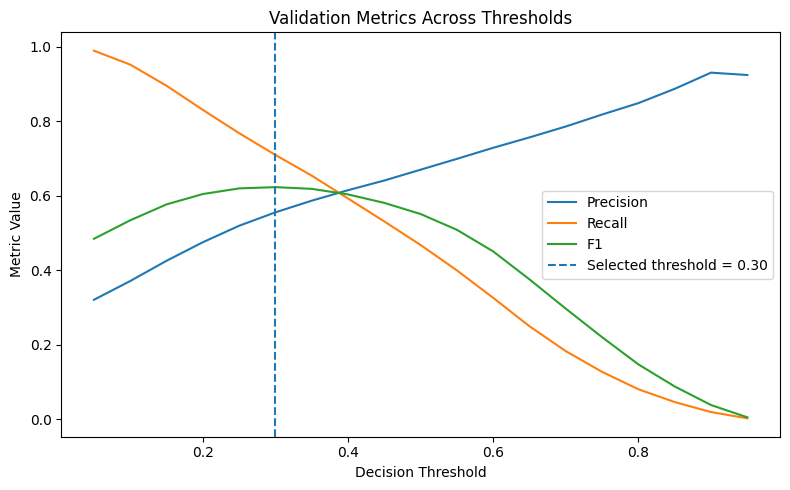

In [55]:
# Cell 7 - Evaluate XGBoost Across Validation Thresholds

threshold_grid = np.arange(0.05, 0.96, 0.05)

threshold_rows = []

for threshold in threshold_grid:
    y_pred = (xgb_val_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "predicted_positive_rate": y_pred.mean()
    })

threshold_results = pd.DataFrame(threshold_rows)

best_f1_row = threshold_results.loc[threshold_results["f1"].idxmax()]
selected_threshold = round(float(best_f1_row["threshold"]), 2)

print("Validation ROC-AUC:", round(roc_auc_score(y_val, xgb_val_proba), 4))
print("Validation PR-AUC:", round(average_precision_score(y_val, xgb_val_proba), 4))
print("Selected operating threshold based on validation F1:", selected_threshold)

threshold_results["threshold_rounded"] = threshold_results["threshold"].round(2)

display(
    threshold_results[
        threshold_results["threshold_rounded"].isin([0.30, 0.40, 0.50, 0.60])
    ][[
        "threshold_rounded",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "predicted_positive_rate"
    ]].rename(columns={"threshold_rounded": "threshold"}).round(4)
)

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")
plt.axvline(selected_threshold, linestyle="--", label=f"Selected threshold = {selected_threshold:.2f}")
plt.title("Validation Metrics Across Thresholds")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Selection

The model outputs probabilities, not direct decisions. A probability threshold is therefore needed to convert predictions into binary BUY NOW or WAIT outputs.

The threshold used for binary evaluation is selected on the validation set by maximising F1 score. This threshold is not selected using the test set.

The binary threshold is useful for comparing models and reporting a confusion matrix. However, it is not the final user-facing recommendation design. For the deployed recommendation logic, a three-zone system is more appropriate because it allows the model to express uncertainty instead of forcing every case into BUY NOW or WAIT.

In [56]:
# Cell 8 - Validation Confusion Matrix at Selected Operating Threshold

xgb_val_pred_selected = (xgb_val_proba >= selected_threshold).astype(int)

cm = confusion_matrix(y_val, xgb_val_pred_selected)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0: no meaningful drop", "Actual 1: meaningful drop"],
    columns=["Predicted 0: buy now", "Predicted 1: wait"]
)

selected_metrics = evaluate_predictions(
    y_true=y_val,
    y_pred=xgb_val_pred_selected,
    y_score=xgb_val_proba,
    model_name=f"XGBoost selected threshold {selected_threshold:.2f}"
)

print("Selected validation threshold:", selected_threshold)
display(pd.DataFrame([selected_metrics]))
display(cm_df)

print("Classification report:")
print(classification_report(
    y_val,
    xgb_val_pred_selected,
    target_names=["No meaningful drop", "Meaningful drop"]
))

Selected validation threshold: 0.3


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost selected threshold 0.30,0.752013,0.555414,0.709344,0.623012,0.813878,0.642376


,Predicted 0: buy now,Predicted 1: wait
Actual 0: no meaningful drop,139878,41936
Actual 1: meaningful drop,21467,52390


Classification report:
                    precision    recall  f1-score   support

No meaningful drop       0.87      0.77      0.82    181814
   Meaningful drop       0.56      0.71      0.62     73857

          accuracy                           0.75    255671
         macro avg       0.71      0.74      0.72    255671
      weighted avg       0.78      0.75      0.76    255671



In [57]:
# Fair Validation Model Comparison

fair_validation_comparison = pd.DataFrame([
    rule_metrics,
    log_reg_metrics,
    log_reg_metrics_selected,
    selected_metrics
])

fair_validation_comparison

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Rule baseline: price above 30-day mean,0.647363,0.435548,0.745793,0.549932,0.740911,0.552914
1,Logistic regression,0.753269,0.702728,0.252853,0.371893,0.769880,0.585083
2,Logistic regression threshold 0.25,0.707437,0.495444,0.694166,0.578207,0.769880,0.585083
3,XGBoost selected threshold 0.30,0.752013,0.555414,0.709344,0.623012,0.813878,0.642376


## Validation Model Comparison

The fair validation comparison shows that XGBoost provides the strongest overall model performance.

The rule baseline is useful because it represents a simple human-designed heuristic: predict a future drop when the current price is above the 30-day average. Logistic regression improves ranking performance but needs threshold tuning to become competitive on F1. XGBoost achieves the best F1 score after validation-based threshold tuning, while also producing the strongest ROC-AUC and PR-AUC.

This supports the use of XGBoost because it adds value beyond both the simple rule baseline and the linear machine-learning baseline.

In [58]:
# Cell 9 - Shopper-Style Backtest on Validation Set

def shopper_backtest(y_true, y_pred, model_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    wait_mask = y_pred == 1
    buy_now_mask = y_pred == 0

    wait_count = wait_mask.sum()
    buy_now_count = buy_now_mask.sum()

    wait_precision = y_true[wait_mask].mean() if wait_count > 0 else np.nan
    missed_drop_rate = y_true[buy_now_mask].mean() if buy_now_count > 0 else np.nan

    return {
        "model": model_name,
        "wait_recommendations": wait_count,
        "buy_now_recommendations": buy_now_count,
        "wait_precision": wait_precision,
        "missed_drop_rate": missed_drop_rate
    }


rule_backtest = shopper_backtest(
    y_true=y_val,
    y_pred=rule_pred_val,
    model_name="Rule baseline"
)

xgb_backtest = shopper_backtest(
    y_true=y_val,
    y_pred=xgb_val_pred_selected,
    model_name=f"XGBoost threshold {selected_threshold:.2f}"
)

backtest_df = pd.DataFrame([rule_backtest, xgb_backtest])

backtest_df["wait_precision"] = (backtest_df["wait_precision"] * 100).round(2)
backtest_df["missed_drop_rate"] = (backtest_df["missed_drop_rate"] * 100).round(2)

backtest_df

,model,wait_recommendations,buy_now_recommendations,wait_precision,missed_drop_rate
0,Rule baseline,126466,129205,43.55,14.53
1,XGBoost threshold 0.30,94326,161345,55.54,13.31


## Shopper-Style Validation Backtest

The shopper-style backtest evaluates the model in terms of recommendation usefulness rather than only statistical classification metrics.

`WAIT precision` measures how often a WAIT recommendation is followed by a meaningful price drop.

`Missed drop rate` measures how often a BUY NOW recommendation is followed by a meaningful price drop, meaning the user would have missed a better buying opportunity.

This evaluation is important because the real goal is not only to maximise accuracy, but to support better buy/wait decisions for deal-conscious shoppers.

In [59]:
# Cell 10 - Three-Zone Recommendation Evaluation on Validation Set

BUY_THRESHOLD = 0.25
WAIT_THRESHOLD = 0.65

zone_df = val_df[["date", "asin", "amazon_price", "label_drop_14d"]].copy()
zone_df["xgb_probability"] = xgb_val_proba

zone_df["recommendation_zone"] = np.select(
    [
        zone_df["xgb_probability"] <= BUY_THRESHOLD,
        zone_df["xgb_probability"] >= WAIT_THRESHOLD
    ],
    [
        "confident_buy",
        "confident_wait"
    ],
    default="uncertain"
)

zone_summary = (
    zone_df
    .groupby("recommendation_zone")
    .agg(
        rows=("label_drop_14d", "count"),
        positive_rate=("label_drop_14d", "mean"),
        avg_probability=("xgb_probability", "mean"),
        avg_price=("amazon_price", "mean")
    )
    .reset_index()
)

zone_summary["row_percentage"] = (zone_summary["rows"] / len(zone_df) * 100).round(2)
zone_summary["positive_rate"] = (zone_summary["positive_rate"] * 100).round(2)
zone_summary["avg_probability"] = zone_summary["avg_probability"].round(3)
zone_summary["avg_price"] = zone_summary["avg_price"].round(2)

zone_summary

,recommendation_zone,rows,positive_rate,avg_probability,avg_price,row_percentage
0,confident_buy,146500,11.71,0.115,63.72,57.30
1,confident_wait,24376,75.65,0.758,132.91,9.53
2,uncertain,84795,45.13,0.431,105.84,33.17


The three-zone validation analysis shows that the model can separate products into low-risk, high-risk, and uncertain buying situations. Rather than forcing every product into a binary decision, the three-zone design makes the recommendation more trustworthy by giving strong BUY NOW or WAIT advice only when the predicted probability is clearly low or high.

In the confident WAIT zone, 75.65% of products were followed by a meaningful 14-day price drop. This suggests that high-probability WAIT recommendations are substantially more reliable than the overall binary WAIT precision.

In the confident BUY zone, only 11.71% of products had a meaningful future drop. Since the positive class represents a missed saving opportunity, this low rate suggests that the model is relatively safe when advising the user to buy now.

The uncertain zone had a positive rate of 45.13%, which confirms that these cases are genuinely ambiguous and should not receive a strong recommendation. This supports a practical recommendation design where the system returns BUY NOW, UNCERTAIN, or WAIT depending on the predicted probability.

The average product price is higher in the confident WAIT zone than in the confident BUY zone. This supports the project framing because the model is more likely to identify waiting opportunities for higher-value, considered purchases where meaningful savings are more likely and more useful to the shopper.


In [60]:
# Cell 11 - Validation Performance by Root Category

category_eval_df = val_df[["root_category", "label_drop_14d"]].copy()
category_eval_df["y_pred"] = xgb_val_pred_selected
category_eval_df["y_score"] = xgb_val_proba

category_rows = []

for category, group in category_eval_df.groupby("root_category"):
    category_rows.append({
        "root_category": category,
        "rows": len(group),
        "positive_rate": group["label_drop_14d"].mean() * 100,
        "precision": precision_score(group["label_drop_14d"], group["y_pred"], zero_division=0),
        "recall": recall_score(group["label_drop_14d"], group["y_pred"], zero_division=0),
        "f1": f1_score(group["label_drop_14d"], group["y_pred"], zero_division=0),
        "roc_auc": roc_auc_score(group["label_drop_14d"], group["y_score"]),
        "pr_auc": average_precision_score(group["label_drop_14d"], group["y_score"])
    })

category_performance = pd.DataFrame(category_rows)

category_performance["positive_rate"] = category_performance["positive_rate"].round(2)
category_performance[["precision", "recall", "f1", "roc_auc", "pr_auc"]] = (
    category_performance[["precision", "recall", "f1", "roc_auc", "pr_auc"]].round(4)
)

category_performance.sort_values("f1", ascending=False)

,root_category,rows,positive_rate,precision,recall,f1,roc_auc,pr_auc
1,Electronics,46706,35.42,0.5787,0.7574,0.6561,0.8012,0.6848
0,Appliances,9711,34.73,0.5857,0.6952,0.6358,0.7853,0.6477
2,Home & Kitchen,89878,29.23,0.5579,0.7226,0.6297,0.8131,0.6382
3,Sports & Outdoors,46701,26.62,0.5430,0.6660,0.5982,0.8102,0.5981
4,Tools & Home Improvement,44826,24.62,0.5252,0.6893,0.5961,0.8246,0.6462
5,Toys & Games,17849,23.56,0.5386,0.6297,0.5806,0.8187,0.5921


## Error Analysis

The category-level evaluation checks whether the model behaves consistently across the six root product categories.

The model performs best on Electronics, Appliances, and Home & Kitchen, which aligns well with the target use case of considered, deferrable purchases. Performance is lower for Toys & Games, Sports & Outdoors, and Tools & Home Improvement, but the model does not collapse in any category.

This suggests that the model generalises reasonably across the covered product groups, while also showing that future work could improve performance using more category-specific data or separate category-level models.

,feature,importance
18,price_vs_rolling_mean_30,0.217230
0,amazon_price,0.088763
12,price_rolling_std_14,0.058370
14,price_rolling_std_30,0.057860
16,price_pct_change_14,0.047507
5,price_lag_1,0.044318
10,price_rolling_std_7,0.042305
17,price_pct_change_30,0.029735
15,price_pct_change_7,0.028248
1,amazon_price_raw_missing,0.019741


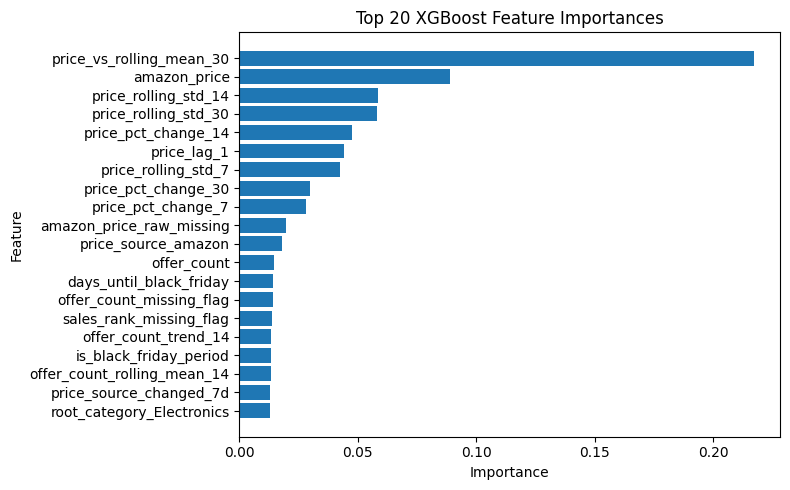

In [61]:
# Cell 12 - XGBoost Feature Importance

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df.head(20).sort_values("importance")["feature"],
    importance_df.head(20).sort_values("importance")["importance"]
)
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature-importance analysis shows that the strongest predictor is `price_vs_rolling_mean_30`, meaning that the model relies heavily on whether the current price is high or low relative to its recent 30-day average. This explains why the simple rule baseline is strong.

However, XGBoost also uses additional signals beyond the rule baseline, including current price level, recent price volatility, recent price changes, Amazon-vs-NEW price source information, offer-count behaviour, Black Friday timing, and product category. This suggests that the model is not only reproducing a manually designed heuristic, but is learning additional interactions around price instability, marketplace structure, and seasonal promotion timing.

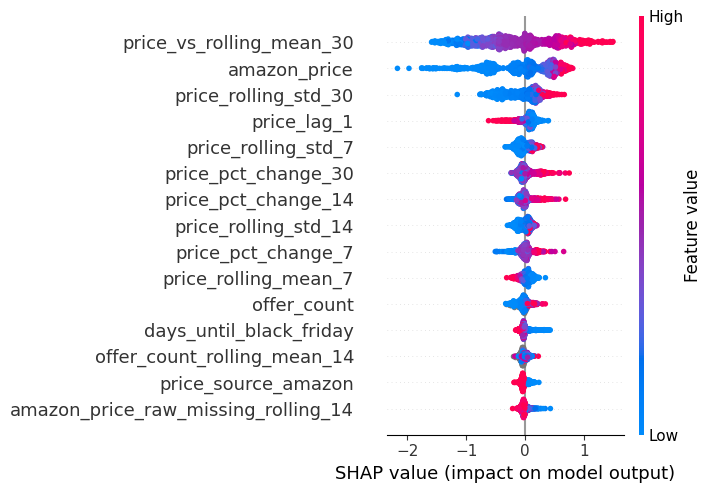

In [69]:
# Cell - SHAP Explainability on Validation Sample

import shap
import matplotlib.pyplot as plt

SHAP_SAMPLE_SIZE = 1000

shap_sample = X_val.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val)),
    random_state=42
)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9
})

shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=15,
    plot_size=(7, 5),
    show=True
)

## SHAP Explainability

The SHAP summary plot confirms that the most influential feature is `price_vs_rolling_mean_30`, meaning the model strongly relies on whether the current price is high or low relative to the recent 30-day average. This supports the intuition behind the rule-based baseline.

However, SHAP also shows that the model uses additional signals, including current price level, rolling price volatility, recent percentage price changes, offer-count behaviour, price-source indicators, and Black Friday timing. This suggests that XGBoost is not only reproducing the simple rule baseline, but is combining multiple historical, marketplace, and seasonal features to estimate the probability of a meaningful 14-day price drop.

In [62]:
# Cell 13 - Final Test Set Evaluation

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_proba >= selected_threshold).astype(int)

test_metrics = evaluate_predictions(
    y_true=y_test,
    y_pred=xgb_test_pred,
    y_score=xgb_test_proba,
    model_name=f"XGBoost test threshold {selected_threshold:.2f}"
)

test_metrics_df = pd.DataFrame([test_metrics])

cm_test = confusion_matrix(y_test, xgb_test_pred)

cm_test_df = pd.DataFrame(
    cm_test,
    index=["Actual 0: no meaningful drop", "Actual 1: meaningful drop"],
    columns=["Predicted 0: buy now", "Predicted 1: wait"]
)

print("Final test evaluation using validation-selected threshold:", selected_threshold)
display(test_metrics_df)
display(cm_test_df)

print("Classification report:")
print(classification_report(
    y_test,
    xgb_test_pred,
    target_names=["No meaningful drop", "Meaningful drop"]
))

Final test evaluation using validation-selected threshold: 0.3


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost test threshold 0.30,0.756038,0.573704,0.721204,0.639054,0.818144,0.657692


,Predicted 0: buy now,Predicted 1: wait
Actual 0: no meaningful drop,52955,15735
Actual 1: meaningful drop,8186,21176


Classification report:
                    precision    recall  f1-score   support

No meaningful drop       0.87      0.77      0.82     68690
   Meaningful drop       0.57      0.72      0.64     29362

          accuracy                           0.76     98052
         macro avg       0.72      0.75      0.73     98052
      weighted avg       0.78      0.76      0.76     98052



In [63]:
# Cell 14 - Final Test Shopper Backtest and Three-Zone Evaluation

test_backtest = shopper_backtest(
    y_true=y_test,
    y_pred=xgb_test_pred,
    model_name=f"XGBoost test threshold {selected_threshold:.2f}"
)

test_backtest_df = pd.DataFrame([test_backtest])
test_backtest_df["wait_precision"] = (test_backtest_df["wait_precision"] * 100).round(2)
test_backtest_df["missed_drop_rate"] = (test_backtest_df["missed_drop_rate"] * 100).round(2)

display(test_backtest_df)

test_zone_df = test_df[["date", "asin", "amazon_price", "label_drop_14d"]].copy()
test_zone_df["xgb_probability"] = xgb_test_proba

test_zone_df["recommendation_zone"] = np.select(
    [
        test_zone_df["xgb_probability"] <= BUY_THRESHOLD,
        test_zone_df["xgb_probability"] >= WAIT_THRESHOLD
    ],
    [
        "confident_buy",
        "confident_wait"
    ],
    default="uncertain"
)

test_zone_summary = (
    test_zone_df
    .groupby("recommendation_zone")
    .agg(
        rows=("label_drop_14d", "count"),
        positive_rate=("label_drop_14d", "mean"),
        avg_probability=("xgb_probability", "mean"),
        avg_price=("amazon_price", "mean")
    )
    .reset_index()
)

test_zone_summary["row_percentage"] = (test_zone_summary["rows"] / len(test_zone_df) * 100).round(2)
test_zone_summary["positive_rate"] = (test_zone_summary["positive_rate"] * 100).round(2)
test_zone_summary["avg_probability"] = test_zone_summary["avg_probability"].round(3)
test_zone_summary["avg_price"] = test_zone_summary["avg_price"].round(2)

display(test_zone_summary)

,model,wait_recommendations,buy_now_recommendations,wait_precision,missed_drop_rate
0,XGBoost test threshold 0.30,36911,61141,57.37,13.39


,recommendation_zone,rows,positive_rate,avg_probability,avg_price,row_percentage
0,confident_buy,55852,11.90,0.114,63.20,56.96
1,confident_wait,10187,76.87,0.765,137.71,10.39
2,uncertain,32013,46.49,0.437,106.32,32.65


## Final Test Interpretation

The final model predicts whether a product will have a meaningful price drop within the next 14 days. A meaningful drop is defined as at least 5% and at least $5 saving.

The final test set uses unseen future data from 2026. The model was not tuned on this test set. The operating threshold of 0.30 was selected using the validation set only.

On the test set, XGBoost achieved ROC-AUC 0.818, PR-AUC 0.658, and F1 0.639. The shopper-style evaluation showed that when the model recommended WAIT, a meaningful drop occurred 57.37% of the time. When it recommended BUY NOW, it missed a meaningful drop only 13.39% of the time.

The three-zone recommendation system provides the most practical result. In the confident WAIT zone, 76.87% of products had a meaningful future drop. In the confident BUY zone, only 11.90% had a meaningful future drop. The uncertain zone had a positive rate of 46.49%, supporting the decision not to force a recommendation when the model is unsure.

In [64]:
# Cell - Save Final Model, Feature Columns, and Metadata

import json

MODEL_PATH = MODEL_DIR / "xgb_price_drop_14d_model.joblib"
FEATURE_COLUMNS_PATH = MODEL_DIR / "feature_columns.json"
METADATA_PATH = MODEL_DIR / "model_metadata.json"

joblib.dump(xgb_model, MODEL_PATH)

with open(FEATURE_COLUMNS_PATH, "w") as f:
    json.dump(feature_cols, f, indent=4)

model_metadata = {
    "model_type": "XGBoost binary classifier",
    "target": "label_drop_14d",
    "prediction_horizon": "14 days",
    "label_definition": "1 if price drops by at least 5% and at least $5 within the next 14 days",
    "selected_threshold": selected_threshold,
    "confident_buy_threshold": BUY_THRESHOLD,
    "confident_wait_threshold": WAIT_THRESHOLD,
    "train_period": "2015-01-31 to 2024-12-31",
    "validation_period": "2025-01-01 to 2025-12-31",
    "test_period": "2026-01-01 to 2026-05-18",
    "test_roc_auc": float(test_metrics["roc_auc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),
    "test_f1": float(test_metrics["f1"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
}

with open(METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved model to:", MODEL_PATH)
print("Saved feature columns to:", FEATURE_COLUMNS_PATH)
print("Saved metadata to:", METADATA_PATH)

Saved model to: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/xgb_price_drop_14d_model.joblib
Saved feature columns to: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/feature_columns.json
Saved metadata to: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/model_metadata.json


## Notebook Summary

This notebook trained and evaluated a 14-day meaningful price-drop prediction model.

The final target is not a simple percentage drop. A positive label requires both:

- at least 5% price reduction
- at least $5 absolute saving

This makes the prediction more aligned with the target user: a deal-conscious shopper making a considered, deferrable purchase.

The notebook compared a rule-based baseline, logistic regression, and XGBoost. The rule baseline was strong because price relative to the 30-day average is a natural signal for future drops. However, XGBoost improved ranking performance and practical recommendation quality by combining this signal with volatility, price-source, offer-count, category, and retail-event features.

The final recommendation design uses three zones:

- BUY NOW when the model predicts low probability of a meaningful drop
- WAIT when the model predicts high probability of a meaningful drop
- UNCERTAIN when the model is not confident enough

This avoids forcing a recommendation when the probability is ambiguous.

On the held-out 2026 test set, the final XGBoost model achieved ROC-AUC 0.818, PR-AUC 0.658, and F1 0.639 using the validation-selected binary threshold of 0.30.

Using the three-zone recommendation design, confident WAIT recommendations were followed by a meaningful price drop in 76.87% of test cases, while confident BUY recommendations missed a meaningful drop in only 11.90% of test cases.

Overall, the final test results support the practical usefulness of the model, especially for confident recommendations.